In [3]:
#%%

# load startup and some utility functions
import os, sys
# exec(open(os.environ['PYTHONSTARTUP']).read())
STARTUP_2026_coldfronts_mhws = "./2026_coldfronts_mhws_startup.py"
exec(open(STARTUP_2026_coldfronts_mhws).read())


# names for locations
names = ['JordanBasin','ScotianShelf1','ScotianShelf2','Pioneer','SlopeN','SlopeS','MAB_North','MAB_south']
# lat, lon for location
# closest ERA 5 locations to initial locations --> provided by Rhys
lat_fronts = [43.5,43,44.5,40.25,41.5,39,40.75,38.5]
lon_fronts = np.array([292,295,296.5,289,295,289,288,285.5])

# Dictionary keyed by location name for convenient coordinate lookup
front_loc = {
    name: {"lat": lat, "lon": lon}
    for name, lat, lon in zip(names, lat_fronts, lon_fronts)
}

#%%

# open cluster for ERA5 data preprocessing
from dask.distributed import Client, LocalCluster

client = Client(n_workers=8, threads_per_worker=4,processes=True,ip="0.0.0.0",memory_limit='6GB')  # Adjust memory limit as needed
# display cluster information in dash board
display(client)  # if print(display) link to dashboard not correct


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://10.128.43.2:8787/status,
Dashboard: http://10.128.43.2:8787/status,Workers: 8
Total threads: 32,Total memory: 44.70 GiB
Status: running,Using processes: True
Comm: tcp://10.128.43.2:34471,Workers: 8
Dashboard: http://10.128.43.2:8787/status,Total threads: 32
Started: Just now,Total memory: 44.70 GiB
Comm: tcp://10.128.43.2:33305,Total threads: 4
Dashboard: http://10.128.43.2:41719/status,Memory: 5.59 GiB
Nanny: tcp://10.128.43.2:39807,


# 1) Extract ERA 5 data

 - extract regional ERA5 data 
 - spatial field for MSLP
 - extract at specific locations

In [4]:
# preprocess function
def preprocess(ds):
    return ds.sel(
        longitude=slice(280, 296),
        latitude=slice(45, 38),
    )

def preprocess2(ds):
    return ds.sel(
        longitude=slice(-80, -64),
        latitude=slice(45, 38),
    )

mslp = xr.open_mfdataset('/srv/cmip6/data/era5/reanalysis/single-levels/6hr/mean_sea_level_pressure/*.nc',
                        preprocess=preprocess,
                        parallel=True,
                        )

temp2m = xr.open_mfdataset('/srv/data/ERA5/*2m_temperature*.nc',
                        preprocess=preprocess2,
                        parallel=True,
                        engine="h5netcdf",
                        )

temp2m = temp2m.rename({"valid_time": "time"}).drop_vars('number')  # rename valid_time to time for consistency
temp2m['longitude'] = (temp2m['longitude'] + 360) % 360  # convert to 0-360 if needed

u10m = xr.open_mfdataset('/srv/cmip6/data/era5/reanalysis/single-levels/6hr/10m_u_component_of_wind/*.nc',
                            preprocess=preprocess,
                            parallel=True,
                            engine="h5netcdf",
                            )


v10m = xr.open_mfdataset('/srv/cmip6/data/era5/reanalysis/single-levels/6hr/10m_v_component_of_wind/*.nc',
                            preprocess=preprocess,
                            parallel=True,
                            engine="h5netcdf",
                            )

latent = xr.open_mfdataset('/srv/cmip6/data/era5/reanalysis/single-levels/6hr/surface_latent_heat_flux/*.nc',
                            preprocess=preprocess,
                            parallel=True,
                            engine="h5netcdf",
                            )

sensible = xr.open_mfdataset('/srv/cmip6/data/era5/reanalysis/single-levels/6hr/instantaneous_surface_sensible_heat_flux/*.nc',
                            preprocess=preprocess,
                            parallel=True,
                            engine="h5netcdf",  
                            )

In [5]:
# load ERA5 sea level pressure for spatial composite

def preprocess3(ds):
    return ds.sel(
        longitude=slice(280, 310),
        latitude=slice(50,35),
    )

mslp_spatial = xr.open_mfdataset('/srv/cmip6/data/era5/reanalysis/single-levels/6hr/mean_sea_level_pressure/*.nc',
                        preprocess=preprocess3,
                        parallel=True,
                        ).sel(time=slice('1983-01-01','2018-12-31')).load()

# 

python: /croot/libnetcdf_1691154366938/work/libsrc4/nc4internal.c:261: nc4_nc4f_list_add: Assertion `nc && !((NC_FILE_INFO_T *)(nc)->dispatchdata) && path' failed.
2026-09-28 11:20:32,851 - distributed.nanny - WARNING - Restarting worker


## Extract MSL spatial data at frontal points

In [7]:
# load cold front data
name = 'Pioneer'
front_cold = xr.open_dataset('../data/coldfront_xr.nc') #{0,1}
wo = (front_cold['front'].sel(loc=name)==1).drop_vars(['lat','lon','loc'])

In [8]:
# extract msl at frontal points
msl_front_mean_loc = {}
for name in names:
    wo = (front_cold['front'].sel(loc=name)==1).drop_vars(['lat','lon','loc'])
    msl_front_mean_loc[name] = mslp_spatial.where(wo,drop=True).mean('time')

In [9]:
# safe to netcdf
pickle_save('era5_msl_front_mean_loc', '../data/', msl_front_mean_loc)

save at:  ../data/era5_msl_front_mean_loc.npy


#------------------------------------------------------------
## extract timeseries data for each location
#------------------------------------------------------------

In [12]:
#------------------------------------------------------------
# extract timeseries data for each location
#------------------------------------------------------------

lats = [43.5,43,44.5,40.25,41.5,39,40.75,38.5]
lons = np.array([292,295,296.5,289,295,289,288,285.5])-360

def extract_loc(ds):
    series = []
    for name, lon0, lat0 in zip(names, lons, lats):
        da_i = ds.sel(
            time=slice("1982-01-01", "2018-12-31")).sel(
            longitude=lon0 % 360, # change to 0-360 for ERA5 data
            latitude=lat0,
            method="nearest",
        ).compute()

        da_i = da_i.expand_dims(loc=[name]) # add location dimension

        # assign coordinates for lon and lat
        da_i = da_i.assign_coords(
            longitude=("loc", [lon0]),
            latitude=("loc", [lat0]),
        )

        # append extracted data to list
        series.append(da_i)

    return xr.concat(series, dim="loc")

mslp_loc = extract_loc(mslp['msl'])
temp2m_loc = extract_loc(temp2m['t2m'])
u10m_loc = extract_loc(u10m['u10'])
v10m_loc = extract_loc(v10m['v10'])
latent_loc = extract_loc(latent['slhf'])
sensible_loc = extract_loc(sensible['ishf'])

## Derive Wind Stress Components

The wind stress magnitude is

$$
\tau = \rho_a C_D U^2,
$$

where the wind speed is

$$
U = \sqrt{u_{10}^2 + v_{10}^2}.
$$

The stress vector is assumed to be parallel to the wind vector, so its components are

$$
\tau_x = \tau \frac{u_{10}}{U},
$$

$$
\tau_y = \tau \frac{v_{10}}{U}.
$$

Substituting the expression for $\tau$ gives

$$
\tau_x = \rho_a C_D U u_{10},
$$

$$
\tau_y = \rho_a C_D U v_{10}.
$$

In [13]:
# derive wind stress
rho_air = 1.225  # mean air density in kg/m^3
speed = np.sqrt(u10m_loc**2 + v10m_loc**2)
Cd = 1.25*1e-3  # mean drag coefficient
tau = rho_air * Cd * speed**2  # wind stress

taux_10m = tau * u10m_loc / speed
tauy_10m = tau * v10m_loc / speed

(17683.0, 17896.0)

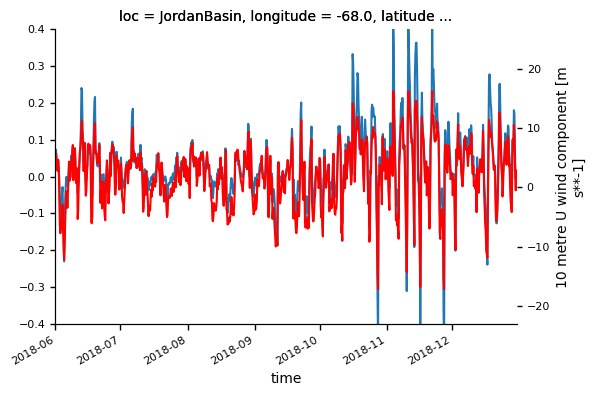

In [14]:
# varify that they are consistent
fig,ax = plt.subplots(figsize=(6,4), sharex=True)
taux_10m[0,::].plot(ax=ax)
ax.set_ylim(-0.4,0.4)
ax2 = ax.twinx()
u10m_loc[0,::].plot(ax=ax2,color='r')
ax.set_xlim(np.datetime64("2018-06-01"), np.datetime64("2018-12-31"))

In [15]:
#------------------------------------------------------------
# create dataset and save to netcdf
#------------------------------------------------------------

era5_loc = mslp_loc.to_dataset()
era5_loc['taux10m'] = taux_10m
era5_loc['tauy10m'] = tauy_10m
era5_loc['ishf'] = sensible_loc
era5_loc['slhf'] = latent_loc[:,:,0] # select final processed data (not real time)
era5_loc['temp2m'] = temp2m_loc

# sum up turbulent fluxes
# not the same units. sensible is instantaneous (W/m^2), latent is 6-hourly accumulated (J/m^2). Need to divide latent by accumulation period to convert to W/m^2
era5_loc['turbulent_flux'] = (sensible_loc + (latent_loc[:,:,0]/(6*3600)))  # total turbulent heat flux


In [16]:

# save to netcdf
era5_loc.to_netcdf('../data/ERA5_loc.nc')

# Build Fig. 4 ERA5 composites for MAB North

This section reuses the processed ERA5 location dataset generated above, loads the frontal and MHW event products, extracts event-centered windows, and saves the MAB North composite figure.

In [18]:
# Load the data products needed for the MAB North event composites.

front_metrics_full = pickle_load("front_metrics_era5_full", "../data/")
interm_loc_6hr = pickle_load("interm_loc_6hr_oisst", "../data/")
mhw_loc_6hr = pickle_load("mhw_loc_6hr_oisst", "../data/")

front_cold = xr.open_dataset("../data/coldfront_xr.nc")
front_warm = xr.open_dataset("../data/warmfront_loc.nc")
era5 = xr.open_dataset("../data/ERA5_loc.nc")
era5["msl"] = era5["msl"] / 100  # Pa to hPa
era5["turbulent_flux"] = era5["ishf"] + era5["slhf"] / (6 * 3600)

load from:  ../data/front_metrics_era5_full.npy
load from:  ../data/interm_loc_6hr_oisst.npy
load from:  ../data/mhw_loc_6hr_oisst.npy


In [19]:
def extract_front_mhw_windows(name, dummy_front, collocation="frontal", mhw_special="", dx=40, var="tempa"):
    """Extract ±5-day temperature windows and classify frontal/MHW coincidence."""
    n_time = 41
    n_event = len(dummy_front["event"])
    temp_comp = np.full((n_time, n_event), np.nan)
    mhw_event_comp = np.full((n_time, n_event), np.nan)
    valid_event = np.zeros(n_event, dtype=bool)

    mhw_short = mhw_loc_6hr[name].where(
        mhw_loc_6hr[name]["duration"] < dx, drop=True
    )["event"]
    mhw_long = mhw_loc_6hr[name].where(
        mhw_loc_6hr[name]["duration"] >= dx, drop=True
    )["event"]

    for i in range(n_event):
        t0 = dummy_front["time_start"][i] - np.timedelta64(5, "D")
        t1 = dummy_front["time_start"][i] + np.timedelta64(5, "D")
        subset = interm_loc_6hr[name].sel(time=slice(t0, t1))
        if len(subset[var]) == n_time:
            temp_comp[:, i] = subset[var].values.squeeze()
            mhw_event_comp[:, i] = subset["events"].values
            valid_event[i] = True

    has_any_event = np.zeros(n_event, dtype=bool)
    for i in range(n_event):
        if collocation == "frontal":
            event_ids = mhw_event_comp[16:21, i]
        elif collocation == "window":
            event_ids = mhw_event_comp[:, i]
        else:
            raise ValueError("collocation must be 'window' or 'frontal'")
        has_any_event[i] = np.any(~np.isnan(event_ids))

    wo_any = valid_event & has_any_event
    if mhw_special:
        target_events = mhw_long if mhw_special == "long" else mhw_short
        has_target = np.zeros(n_event, dtype=bool)
        for i in range(n_event):
            event_ids = (
                np.unique(mhw_event_comp[16:21, i])
                if collocation == "frontal"
                else np.unique(mhw_event_comp[:, i])
            )
            event_ids = event_ids[~np.isnan(event_ids)].astype(int)
            if event_ids.size and np.any(np.isin(event_ids, target_events)):
                has_target[i] = True
        wo = wo_any & has_target
    else:
        wo = wo_any

    wo_no_mhw = valid_event & ~wo_any
    return temp_comp, wo, wo_no_mhw


def compute_avg_ts(event_array, method="event_centered", time=None):
    """Normalize event series if requested and return timestep-wise mean and std."""
    if event_array.size == 0:
        n_time = event_array.shape[0] if event_array.ndim == 2 else 0
        empty = np.full(n_time, np.nan)
        return empty, empty

    data = event_array.copy()
    if method == "absolute":
        data_norm = data
    elif method == "event_centered":
        data_norm = data - np.nanmean(data, axis=0, keepdims=True)
    elif method == "pre_event":
        if time is None:
            raise ValueError("time is required for 'pre_event' normalization")
        i_zero = int(np.where(time == 0)[0][0])
        data_norm = data - np.nanmean(data[:i_zero, :], axis=0, keepdims=True)
    else:
        raise ValueError("method must be 'absolute', 'event_centered', or 'pre_event'")

    return np.nanmean(data_norm, axis=1), np.nanstd(data_norm, axis=1)


def extract_front_era5_windows(name, dummy_front, dataset, var):
    """Extract a 41-step, ±5-day ERA5 window for each frontal event."""
    n_time = 41
    event_windows = np.full((n_time, len(dummy_front["event"])), np.nan)
    for i in range(len(dummy_front["event"])):
        t0 = dummy_front["time_start"][i] - np.timedelta64(5, "D")
        t1 = dummy_front["time_start"][i] + np.timedelta64(5, "D")
        subset = dataset.sel(loc=name)[var].sel(time=slice(t0, t1))
        if len(subset) == n_time:
            event_windows[:, i] = subset.values
    return event_windows

In [20]:
# Extract ERA5 and frontal-binary windows for MAB North.
name = "MAB_North"
method = "event_centered"
time = np.arange(-5 * 24, 5 * 24 + 6, 6)

era5_comp_loc = {}
for region in names:
    era5_comp = {
        var: extract_front_era5_windows(region, front_metrics_full[region], era5, var)
        for var in era5.data_vars
    }
    _, wo_mhw_short, wo_no_mhw = extract_front_mhw_windows(
        region, front_metrics_full[region], collocation="frontal", mhw_special="short"
    )
    _, wo_mhw_long, _ = extract_front_mhw_windows(
        region, front_metrics_full[region], collocation="frontal", mhw_special="long"
    )
    era5_comp.update({
        "wo_mhw_short": wo_mhw_short,
        "wo_mhw_long": wo_mhw_long,
        "wo_no_mhw": wo_no_mhw,
    })
    era5_comp_loc[region] = era5_comp

# Front-occurrence fractions are calculated for the same region shown in the figure.
comp_warm = extract_front_era5_windows(
    name, front_metrics_full[name], front_warm, var="F_warm"
)
comp_cold = extract_front_era5_windows(
    name, front_metrics_full[name], front_cold, var="front"
)
warm_frontal_percentage = np.nansum(comp_warm, axis=-1) / comp_warm.shape[-1]
cold_frontal_percentage = np.nansum(comp_cold, axis=-1) / comp_cold.shape[-1]

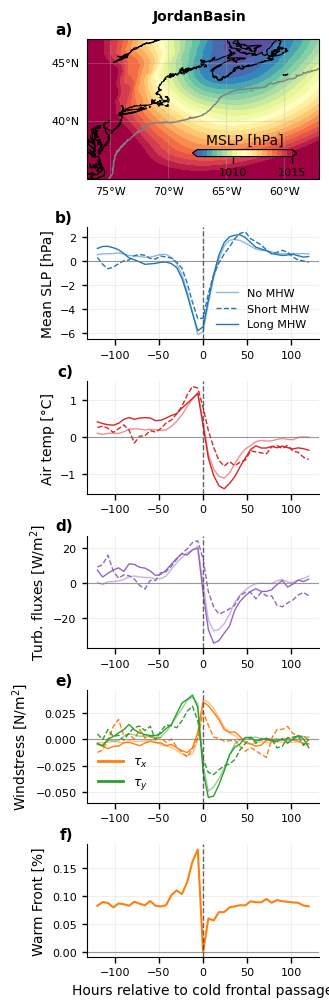

In [28]:
# ------------------------------------------------------------
# plotting ERA5 composites with map of mean SLP
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def add_panel_labels(axes, labels=None, x=-0.06, y=1.02, **text_kwargs):
    """Place sequential panel labels just outside each axes' upper-left corner."""
    if labels is None:
        labels = [f"{chr(ord('a') + i)})" for i in range(len(axes))]
    if len(labels) != len(axes):
        raise ValueError("Provide one panel label per axes")

    style = {"fontsize": 11, "fontweight": "bold", "ha": "right", "va": "bottom"}
    style.update(text_kwargs)
    for ax, label in zip(axes, labels):
        ax.text(x, y, label, transform=ax.transAxes, clip_on=False, **style)


name = "JordanBasin"
method = "event_centered"
time = np.arange(-5 * 24, 5 * 24 + 6, 6)

plot_groups = [
    {"variables": ["msl"], "title": "Mean SLP [hPa]", "colors": ["tab:blue"], "labels": ["MSLP"]},
    {"variables": ["temp2m"], "title": "Air temp [°C]", "colors": ["tab:red"], "labels": ["2-m temperature"]},
    {"variables": ["turbulent_flux"], "title": "Turb. fluxes [W/m$^2$]", "colors": ["tab:purple"], "labels": ["Turbulent fluxes"]},
    {"variables": ["taux10m", "tauy10m"], "title": "Windstress [N/m$^2$]", "colors": ["tab:orange", "tab:green"], "labels": [r"$\tau_x$", r"$\tau_y$"]},
]

nrows = len(plot_groups) + 2
fig = plt.figure(figsize=(3, 12))
gs = fig.add_gridspec(nrows, 1, height_ratios=[1.35] + [1] * (nrows - 1), hspace=0.35)
ax0 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
axes = [ax0] + [fig.add_subplot(gs[i, 0]) for i in range(1, nrows)]

# map
ax = axes[0]
ax.set_extent([-77, -57, 35, 47], crs=ccrs.PlateCarree())
ax.coastlines(resolution="10m", linewidth=0.8)
# ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linestyle='-',alpha=0.3,
                      xlocs=range(-120,40,5),ylocs=range(0,80,5),x_inline=False)
#     gl.xlocator = mticker.FixedLocator(np.arange(-80,-40,5))
#     gl.ylocator = mticker.FixedLocator([10, 20, 30, 40, 50])
gl.rotate_labels = False
gl.top_labels = False
gl.right_labels = False
cc = (msl_front_mean_loc[name]["msl"] / 100).plot.contourf(
    ax=ax, levels=20, cmap="Spectral_r", vmin=1007, vmax=1015, add_colorbar=False, transform=ccrs.PlateCarree()
)
ax.contour(bathy.x,bathy.y,(bathy.z*(-1)),levels=[1000],colors='gray',transform=ccrs.PlateCarree(),linewidths=1)
# ax.set_title("Mean sea level pressure", fontsize=11)
cax = inset_axes(ax, width="45%", height="5%", loc="lower right", borderpad=2)
cb = plt.colorbar(cc, cax=cax, orientation="horizontal", ticks=[1010, 1015])
cb.set_label("MSLP [hPa]")
cb.ax.xaxis.set_label_position("top")
cb.ax.minorticks_off()
# cb.ax.tick_params(which="major", length=4)

# composite evolution plots
for ax, group in zip(axes[1:-1], plot_groups):
    for var, color, label in zip(group["variables"], group["colors"], group["labels"]):
        var_all_mean, var_all_std = compute_avg_ts(era5_comp_loc[name][var], method=method, time=time)
        var_short_mhw_mean, _ = compute_avg_ts(era5_comp_loc[name][var][:, era5_comp_loc[name]["wo_mhw_short"]], method=method, time=time)
        var_long_mhw_mean, _ = compute_avg_ts(era5_comp_loc[name][var][:, era5_comp_loc[name]["wo_mhw_long"]], method=method, time=time)
        ax.plot(time, var_all_mean, color=color, lw=1, alpha=0.5, label="No MHW")
        ax.plot(time, var_short_mhw_mean, color=color, lw=1, ls="--", label="Short MHW")
        ax.plot(time, var_long_mhw_mean, color=color, lw=1, label="Long MHW")
    ax.set_ylabel(group["title"])
axes[-1].plot(time, warm_frontal_percentage, color="tab:orange", label="Warm front")
# axes[-1].plot(time, cold_frontal_percentage, color="tab:blue", label="Cold front")
axes[-1].set_ylabel("Warm Front [%]")
axes[-1].set_xlabel("Hours relative to cold frontal passage")

for axh in axes[1:]:
    axh.axhline(0, color="0.45", lw=0.8, alpha=0.7)
    axh.axvline(0, color="0.25", lw=1, ls="--", alpha=0.8)
    axh.grid(alpha=0.2)

axes[-2].legend(handles=[Line2D([0], [0], color="tab:orange", lw=2, label=r"$\tau_x$"), Line2D([0], [0], color="tab:green", lw=2, label=r"$\tau_y$")], frameon=False, loc="best", fontsize=9)
axes[1].legend(frameon=False, loc="best", fontsize=8)

add_panel_labels(axes)
fig.suptitle(f"{name}", y=0.9)
plt.show()

# finished_plot(fig,f'../plots/manuscript/fig4_era5_composites_{name}.jpg', dpi=300)